In [42]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import numpy as np
import seaborn as sns
from enum import Enum
import json
from pathlib import Path

In [43]:
# results_csv_path = "../../icospheres_fixed_size_distance_sweep_2026-09-18_21-37-26_1000faces_0.5radius.csv"
results_csv_path = "../../icospheres_fixed_size_distance_sweep_2026-09-19_15-44-11_2885faces_0.0946radius.csv"

# CSV written by the generator script (columns: case, file_name,
# target_distance, achieved_distance). Used as data source for distance between colliders.
sidecar_csv_path = "../../data/icospheres_fixed_size_distance_sweep/target_distances.csv"

df = pd.read_csv(results_csv_path)
dist_df = pd.read_csv(sidecar_csv_path)

from algo_metadata import algo_metadata

In [44]:
sns.set_theme(style="whitegrid")

# Pick which algorithms (result-CSV column names) to compare:
algos_to_compare = [
    "FCL intersection",
    "FCL intersection defaultGJK",
    # "FCL distance linear support",
    # "FCL distance defaultGJK linear support",
    "FCL distance",
    "FCL distance defaultGJK",
    # "distance3d Nesterov (with acceleration)",
    # "distance3d Nesterov",
    # "collision-rs_nasterov_gjk",
    # "collision-rs_distance_gjk",
    # "openGJK distance"
]

# What the values in the result CSV represent -- only used for axis labels below.
Y_LABEL = "Time per Collision Query [µs]"

df_part = df.copy(deep=True)
for algo in df_part.columns:
    if algo not in algos_to_compare and algo != "file":
        df_part.drop(algo, axis=1, inplace=True)

df_long = df_part.melt(id_vars=['file'], var_name='Algorithm', value_name='Value')
df_long['PrettyName'] = df_long['Algorithm'].map(lambda name: algo_metadata[name].pretty_name_full)

# Attach the signed distance for each case:
dist_lookup = dist_df.set_index('case')[['target_distance', 'achieved_distance']]
df_long = df_long.join(dist_lookup, on='file')
df_long = df_long.dropna(subset=['target_distance'])

pretty_names = df_long["PrettyName"].unique().tolist()
palette = dict(zip(pretty_names, sns.color_palette('Set2', n_colors=len(pretty_names))))

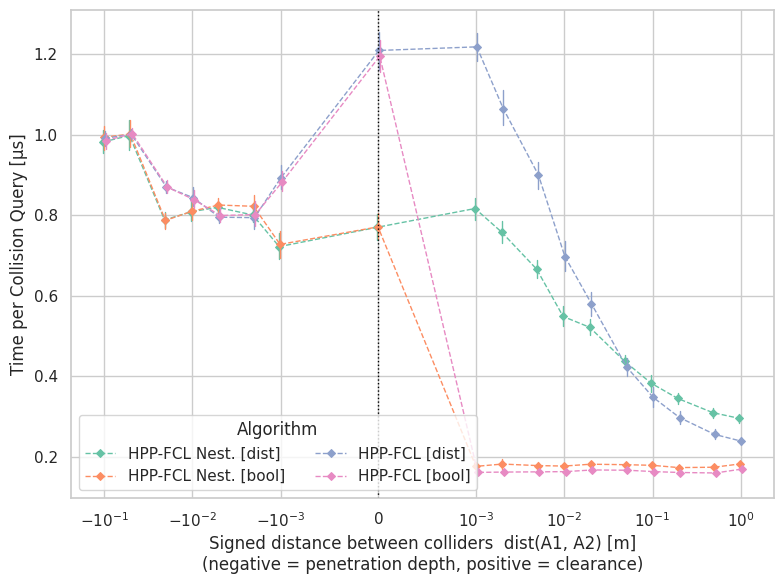

In [45]:
# plot mean value vs. signed distance

fig, ax = plt.subplots(figsize=(8, 6))
# Log scales must be set BEFORE plotting so native_scale positioning accounts for them
ax.set_xscale('symlog', linthresh=1e-3)

sns.pointplot(
    data=df_long, x='target_distance', y='Value',
    hue='PrettyName', hue_order=pretty_names,
    palette=palette,
    dodge=0.1 if len(algos_to_compare) > 1 else False,
    native_scale=True,
    estimator=np.mean,
    # errorbar='sd',
    markers='D', markersize=4, linestyle='--', linewidth=1,
    ax=ax
)


ax.axvline(0.0, color='black', linewidth=1, linestyle=':')
ax.grid(True)
ax.set_xlabel("Signed distance between colliders  dist(A1, A2) [m]\n(negative = penetration depth, positive = clearance)")
ax.set_ylabel(Y_LABEL)

if len(algos_to_compare) > 1:
    ax.legend(title='Algorithm', loc='best', ncol=2)
else:
    ax.legend().remove()

plt.tight_layout()
plt.show()

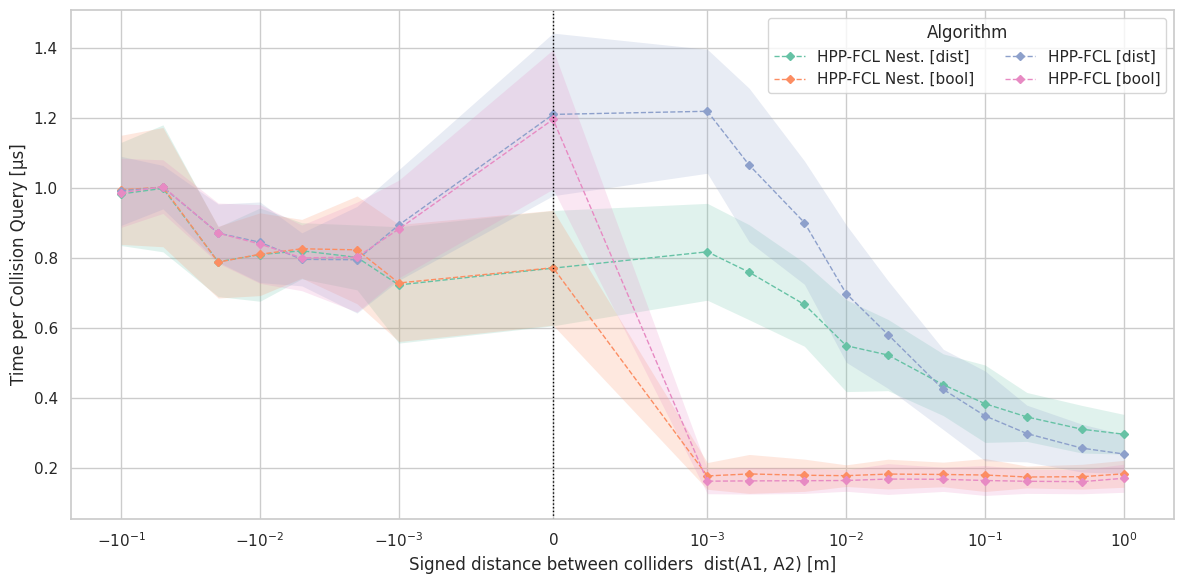

In [46]:
# same plot as above, just with error areas instead of error bars:
fig, ax = plt.subplots(figsize=(12, 6))
# Log scales must be set BEFORE plotting so positions account for them
ax.set_xscale('symlog', linthresh=1e-3)

stats_df = (
    df_long.groupby(['PrettyName', 'target_distance'])['Value']
    .agg(['mean', 'std'])
    .reset_index()
)

for name in pretty_names:
    group = stats_df[stats_df['PrettyName'] == name].sort_values('target_distance')
    color = palette[name]
    ax.plot(
        group['target_distance'], group['mean'],
        marker='D', markersize=4, linestyle='--', linewidth=1,
        color=color, label=name
    )
    ax.fill_between(
        group['target_distance'], group['mean'] - group['std'], group['mean'] + group['std'],
        color=color, alpha=0.2, linewidth=0
    )

ax.axvline(0.0, color='black', linewidth=1, linestyle=':')
ax.grid(True)
ax.set_xlabel("Signed distance between colliders  dist(A1, A2) [m]")
ax.set_ylabel(Y_LABEL)

if len(algos_to_compare) > 1:
    ax.legend(title='Algorithm', loc='best', ncol=2)
else:
    ax.legend().remove()

plt.tight_layout()
plt.show()

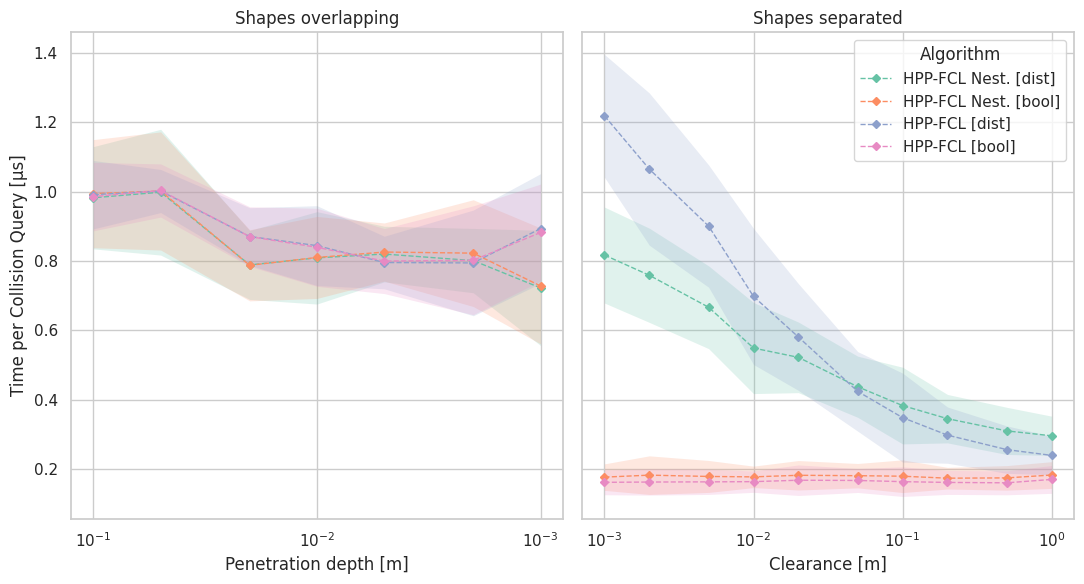

In [47]:
# same plots as above, but split into two halves
penetrating = df_long[df_long['target_distance'] < 0].copy()
penetrating['AbsDistance'] = -penetrating['target_distance']
separated = df_long[df_long['target_distance'] > 0].copy()

pen_stats = (
    penetrating.groupby(['PrettyName', 'AbsDistance'])['Value']
    .agg(['mean', 'std'])
    .reset_index()
)
sep_stats = (
    separated.groupby(['PrettyName', 'target_distance'])['Value']
    .agg(['mean', 'std'])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)

axes[0].set_xscale('log')
for name in pretty_names:
    group = pen_stats[pen_stats['PrettyName'] == name].sort_values('AbsDistance')
    if len(group) == 0:
        continue
    color = palette[name]
    axes[0].plot(
        group['AbsDistance'], group['mean'],
        marker='D', markersize=4, linestyle='--', linewidth=1,
        color=color, label=name
    )
    axes[0].fill_between(
        group['AbsDistance'], group['mean'] - group['std'], group['mean'] + group['std'],
        color=color, alpha=0.2, linewidth=0
    )
axes[0].invert_xaxis()  # 0 on the right, next to the "separated" panel
axes[0].grid(True)
axes[0].set_xlabel("Penetration depth [m]")
axes[0].set_ylabel(Y_LABEL)
axes[0].set_title("Shapes overlapping")

axes[1].set_xscale('log')
for name in pretty_names:
    group = sep_stats[sep_stats['PrettyName'] == name].sort_values('target_distance')
    if len(group) == 0:
        continue
    color = palette[name]
    axes[1].plot(
        group['target_distance'], group['mean'],
        marker='D', markersize=4, linestyle='--', linewidth=1,
        color=color, label=name
    )
    axes[1].fill_between(
        group['target_distance'], group['mean'] - group['std'], group['mean'] + group['std'],
        color=color, alpha=0.2, linewidth=0
    )
axes[1].grid(True)
axes[1].set_xlabel("Clearance [m]")
axes[1].set_title("Shapes separated")

if len(algos_to_compare) > 1:
    axes[1].legend(title='Algorithm', loc='best')
else:
    axes[1].legend().remove()

plt.tight_layout()
plt.show()

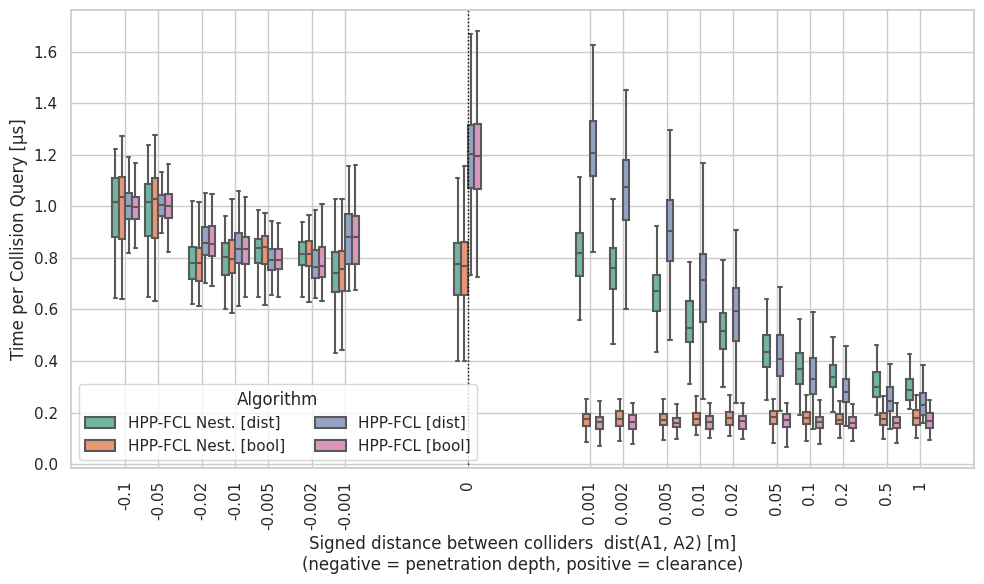

In [48]:
# --- Plot 3: box plot per (discrete, controlled) target distance value --
# same visual style as the distance-binned box plot in
# analysis_icospheres.ipynb, but using the exact controlled target distances
# from the generator script directly instead of post-hoc distance bins
# (unnecessary here since the generator already fixes the distance values
# and samples NUM_POSES_PER_DISTANCE random poses at each one). ---

fig, ax = plt.subplots(figsize=(10, 6))
# Log scales must be set BEFORE plotting so native_scale positioning accounts for them
ax.set_xscale('symlog', linthresh=1e-3)

sns.boxplot(
    data=df_long, x='target_distance', y='Value',
    hue='PrettyName', hue_order=pretty_names,
    palette=palette, dodge=True, native_scale=True,
    linewidth=1.5,
    fliersize=2,
    showfliers=False,
    ax=ax
)

ax.axvline(0.0, color='black', linewidth=1, linestyle=':')
ax.grid(True)
ax.set_xlabel("Signed distance between colliders  dist(A1, A2) [m]\n(negative = penetration depth, positive = clearance)")
ax.set_ylabel(Y_LABEL)

# Show the exact controlled target-distance values as x-tick labels
target_values = sorted(df_long['target_distance'].unique())
ax.set_xticks(target_values)
ax.set_xticklabels([f"{d:.3g}" for d in target_values])
ax.tick_params(axis='x', labelrotation=90)

if len(algos_to_compare) > 1:
    ax.legend(title='Algorithm', loc='best', ncol=2)
else:
    ax.legend().remove()

plt.tight_layout()
plt.show()